basophil       1212
eosinophil     3110
erythroblast   1551
ig             2892
lymphocyte     1214
monocyte       1419
neutrophil     3328
platelet       2348
Total: 17074


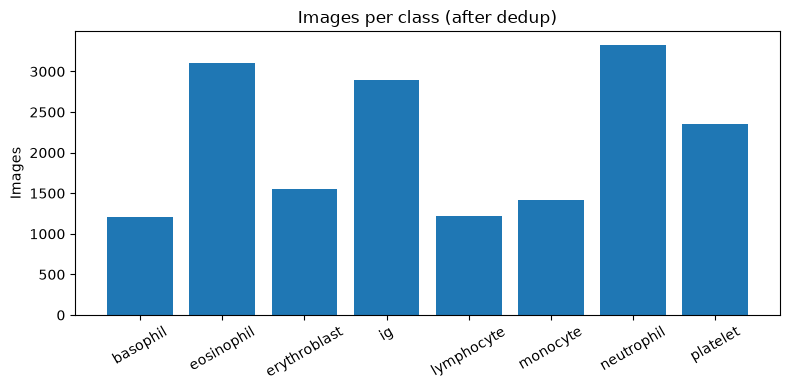

In [2]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image

SEED = 11
random.seed(SEED)

data_dir = Path("../data/blood")
class_names = sorted(p.name for p in data_dir.iterdir() if p.is_dir())
counts = {c: len(list((data_dir / c).glob("*.jpg"))) for c in class_names}

for c, n in counts.items():
    print(f"{c:14s} {n}")
print("Total:", sum(counts.values()))

plt.figure(figsize=(8, 4))
plt.bar(class_names, counts.values())
plt.title("Images per class (after dedup)")
plt.ylabel("Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../images/blood_class_counts.png", dpi=200, bbox_inches="tight")
plt.show()

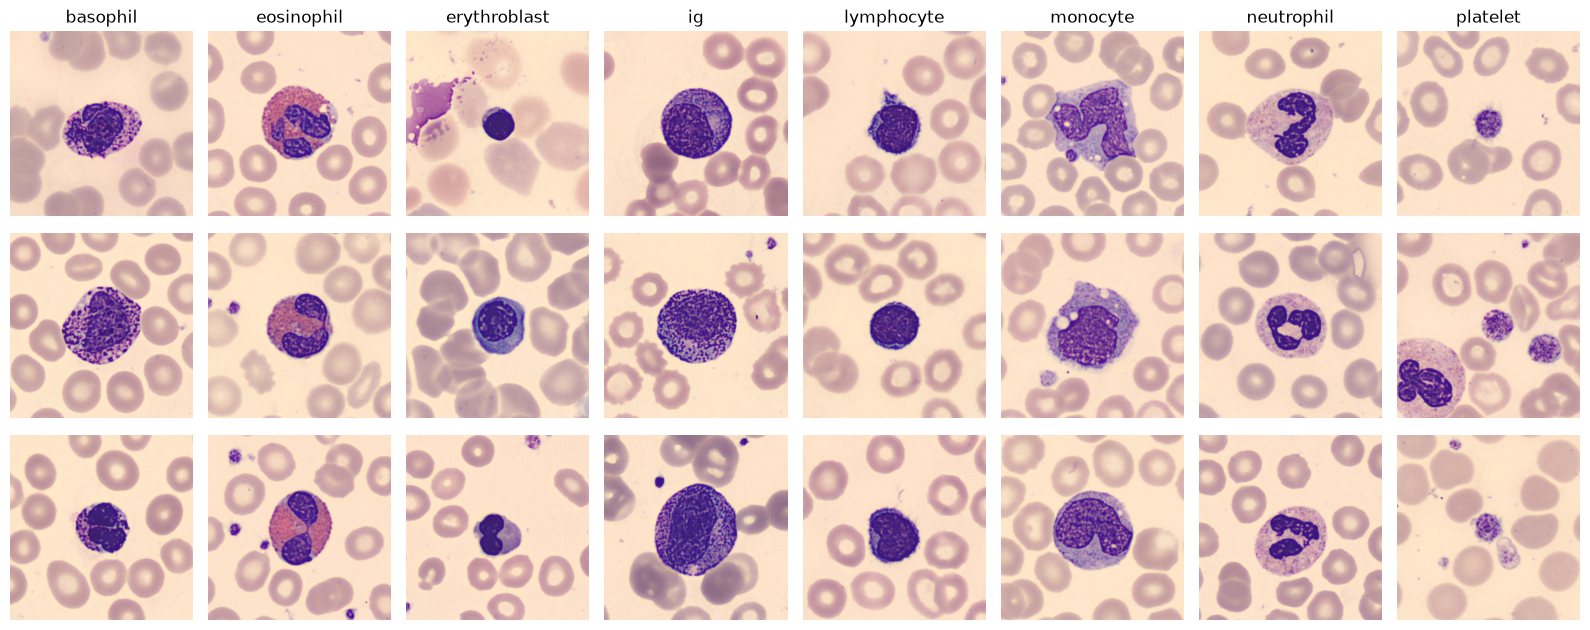

In [2]:
n_rows = 3
fig, axes = plt.subplots(n_rows, len(class_names), figsize=(16, 6.5))

for col, c in enumerate(class_names):
    files = random.sample(sorted((data_dir / c).glob("*.jpg")), n_rows)
    for row, f in enumerate(files):
        ax = axes[row, col]
        ax.imshow(Image.open(f))
        ax.axis("off")
        if row == 0:
            ax.set_title(c)

plt.tight_layout()
plt.savefig("../images/blood_samples.png", dpi=200, bbox_inches="tight")
plt.show()


# Splitting

In [3]:
import json
from collections import Counter
from sklearn.model_selection import train_test_split

# Paths relative to data_dir, so both the notebook and the script can use them
paths, labels = [], []
for label, c in enumerate(class_names):
    for f in sorted((data_dir / c).glob("*.jpg")):
        paths.append(f"{c}/{f.name}")
        labels.append(label)

# 70% train, then split the remaining 30% in half: 15% val, 15% test
train_p, temp_p, train_y, temp_y = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=SEED)
val_p, test_p, val_y, test_y = train_test_split(
    temp_p, temp_y, test_size=0.50, stratify=temp_y, random_state=SEED)

print("train / val / test:", len(train_p), len(val_p), len(test_p))
for name, y in [("train", train_y), ("val", val_y), ("test", test_y)]:
    print(f"{name:5s}", [Counter(y)[i] for i in range(len(class_names))])

split = {"class_names": class_names,
         "train": list(zip(train_p, train_y)),
         "val":   list(zip(val_p, val_y)),
         "test":  list(zip(test_p, test_y))}
Path("../results").mkdir(exist_ok=True)
with open("../results/blood_split.json", "w") as f:
    json.dump(split, f)


train / val / test: 11951 2561 2562
train [848, 2177, 1086, 2024, 850, 993, 2329, 1644]
val   [182, 466, 233, 434, 182, 213, 499, 352]
test  [182, 467, 232, 434, 182, 213, 500, 352]


# Before / After Resize
Evidences for Task 2

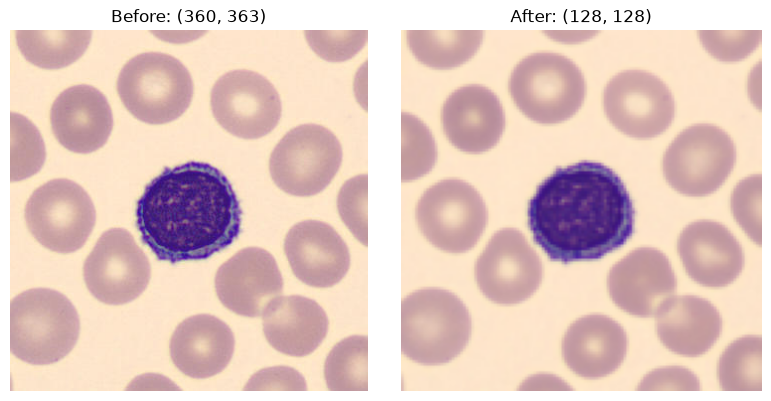

In [4]:
IMG_SIZE = 128
example = data_dir / train_p[0]
orig = Image.open(example)
resized = orig.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(orig);    ax[0].set_title(f"Before: {orig.size}")
ax[1].imshow(resized); ax[1].set_title(f"After: {resized.size}")
for a in ax: a.axis("off")
plt.tight_layout()
plt.savefig("../images/blood_before_after_resize.png", dpi=200, bbox_inches="tight")
plt.show()


In [3]:
import sys
sys.path.insert(0, "../scripts")
from blood_data import load_split, make_dataset # modular functions from scripts/blood_data.py

split = load_split()
train_ds = make_dataset(split, "train", shuffle=True)
val_ds   = make_dataset(split, "val")
test_ds  = make_dataset(split, "test")

x_batch, y_batch = next(iter(train_ds))
print("batch:", x_batch.shape, x_batch.dtype)
print("pixel range:", float(x_batch.numpy().min()), "-", float(x_batch.numpy().max()))
print("labels:", y_batch.numpy()[:10])


batch: (32, 128, 128, 3) <dtype: 'float32'>
pixel range: 0.0117647061124444 - 1.0
labels: [1 1 0 6 6 2 1 1 2 1]


# Data Augmentation

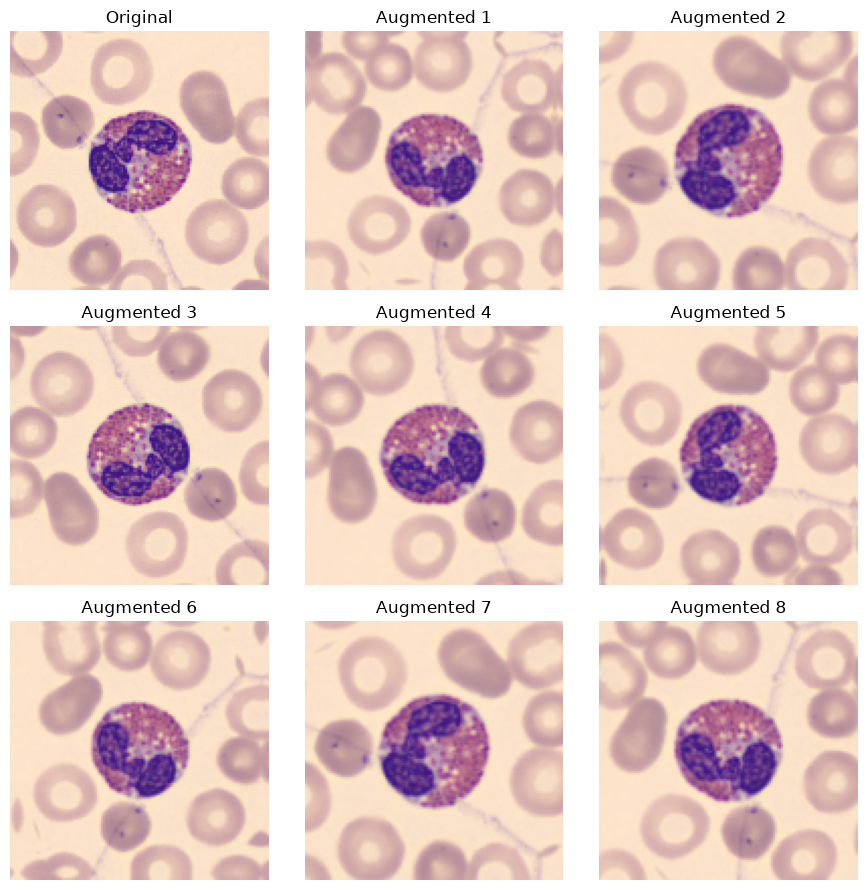

In [ ]:
from blood_model import make_augmentation

augment = make_augmentation()
img = x_batch[:1]  # one training image, shape (1, 128, 128, 3)

plt.figure(figsize=(9, 9))
plt.subplot(3, 3, 1)
plt.imshow(img[0].numpy()); plt.title("Original"); plt.axis("off")
for i in range(2, 10):
    aug = augment(img, training=True)
    plt.subplot(3, 3, i)
    plt.imshow(aug[0].numpy()); plt.title(f"Augmented {i-1}"); plt.axis("off")
plt.tight_layout()
plt.savefig("../images/blood_augmentation_examples.png", dpi=200, bbox_inches="tight")
plt.show()


# Build + Summary

In [7]:
import importlib, blood_model
importlib.reload(blood_model)  # pick up the file edit without restarting the kernel
from blood_model import build_model

model = build_model()
model.summary()


Model: "blood_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,328 (2.05 MB)

 Trainable params: 536,328 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

# Epoch 1+2 test

In [8]:
import time

start = time.time()
timing = model.fit(train_ds, validation_data=val_ds, epochs=2)
print(f"Total: {time.time() - start:.0f} s")


Epoch 1/2


/Users/tituslogo/miniforge3/envs/cnn-assignment/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


374/374 ━━━━━━━━━━━━━━━━━━━━ 67s 177ms/step - accuracy: 0.5789 - loss: 1.1119 - val_accuracy: 0.5857 - val_loss: 1.2173
Epoch 2/2
374/374 ━━━━━━━━━━━━━━━━━━━━ 69s 185ms/step - accuracy: 0.7846 - loss: 0.5824 - val_accuracy: 0.6818 - val_loss: 1.0024
Total: 136 s


# Curves

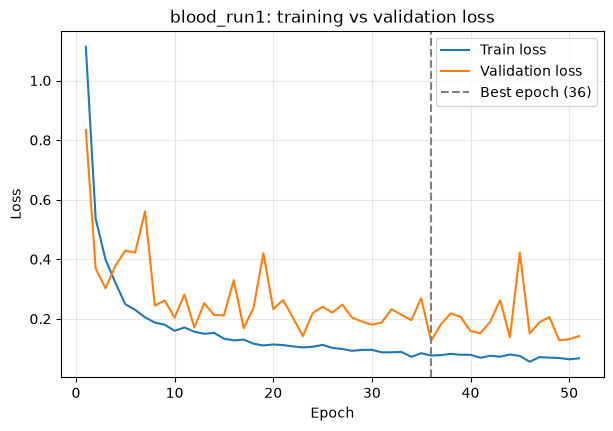

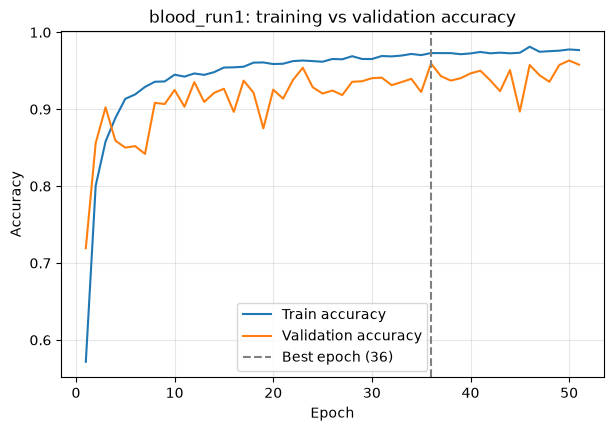

In [9]:
with open("../results/history_blood_run1.json") as f:
    h = json.load(f)["history"]

epochs = range(1, len(h["loss"]) + 1)
best = h["val_loss"].index(min(h["val_loss"])) + 1

for metric, label in [("loss", "Loss"), ("accuracy", "Accuracy")]:
    plt.figure(figsize=(7, 4.5))
    plt.plot(epochs, h[metric], label=f"Train {label.lower()}")
    plt.plot(epochs, h[f"val_{metric}"], label=f"Validation {label.lower()}")
    plt.axvline(best, color="gray", linestyle="--", label=f"Best epoch ({best})")
    plt.xlabel("Epoch"); plt.ylabel(label)
    plt.title(f"blood_run1: training vs validation {label.lower()}")
    plt.legend(); plt.grid(alpha=0.3)
    plt.savefig(f"../images/blood_run1_{metric}_curve.png", dpi=200, bbox_inches="tight")
    plt.show()


# Evaluation
Run only ONCE

Test accuracy: 0.9625   Test loss: 0.1195
              precision    recall  f1-score   support

    basophil      0.882     0.989     0.933       182
  eosinophil      0.998     0.998     0.998       467
erythroblast      1.000     0.957     0.978       232
          ig      0.882     0.933     0.907       434
  lymphocyte      0.988     0.929     0.958       182
    monocyte      0.953     0.864     0.906       213
  neutrophil      0.990     0.976     0.983       500
    platelet      0.997     1.000     0.999       352

    accuracy                          0.963      2562
   macro avg      0.961     0.956     0.958      2562
weighted avg      0.964     0.963     0.963      2562



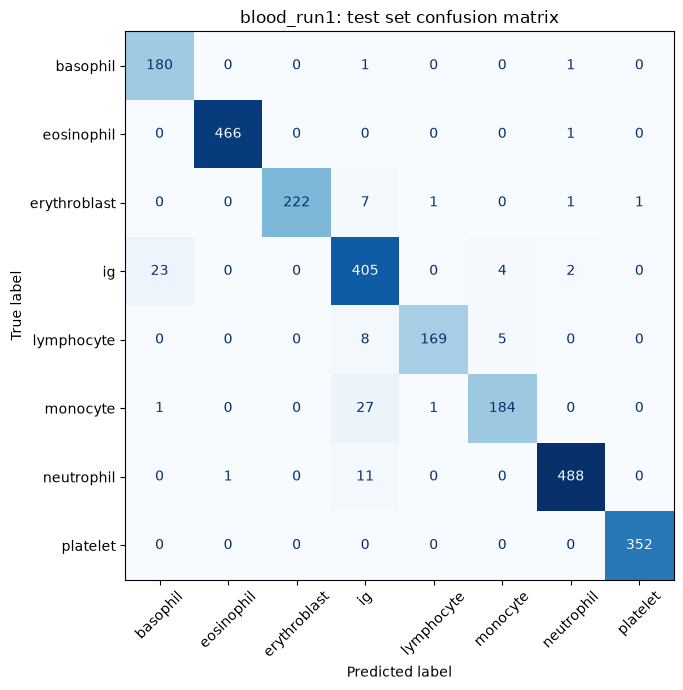

In [4]:
import numpy as np
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

best_model = keras.models.load_model("../results/blood_run1_best.keras")

test_loss, test_acc = best_model.evaluate(test_ds, verbose=0)
print(f"Test accuracy: {test_acc:.4f}   Test loss: {test_loss:.4f}")

y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred = np.argmax(best_model.predict(test_ds, verbose=0), axis=1)

print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
ax.set_title("blood_run1: test set confusion matrix")
plt.tight_layout()
plt.savefig("../images/blood_run1_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()


# Misclassifications

96 misclassified of 2562


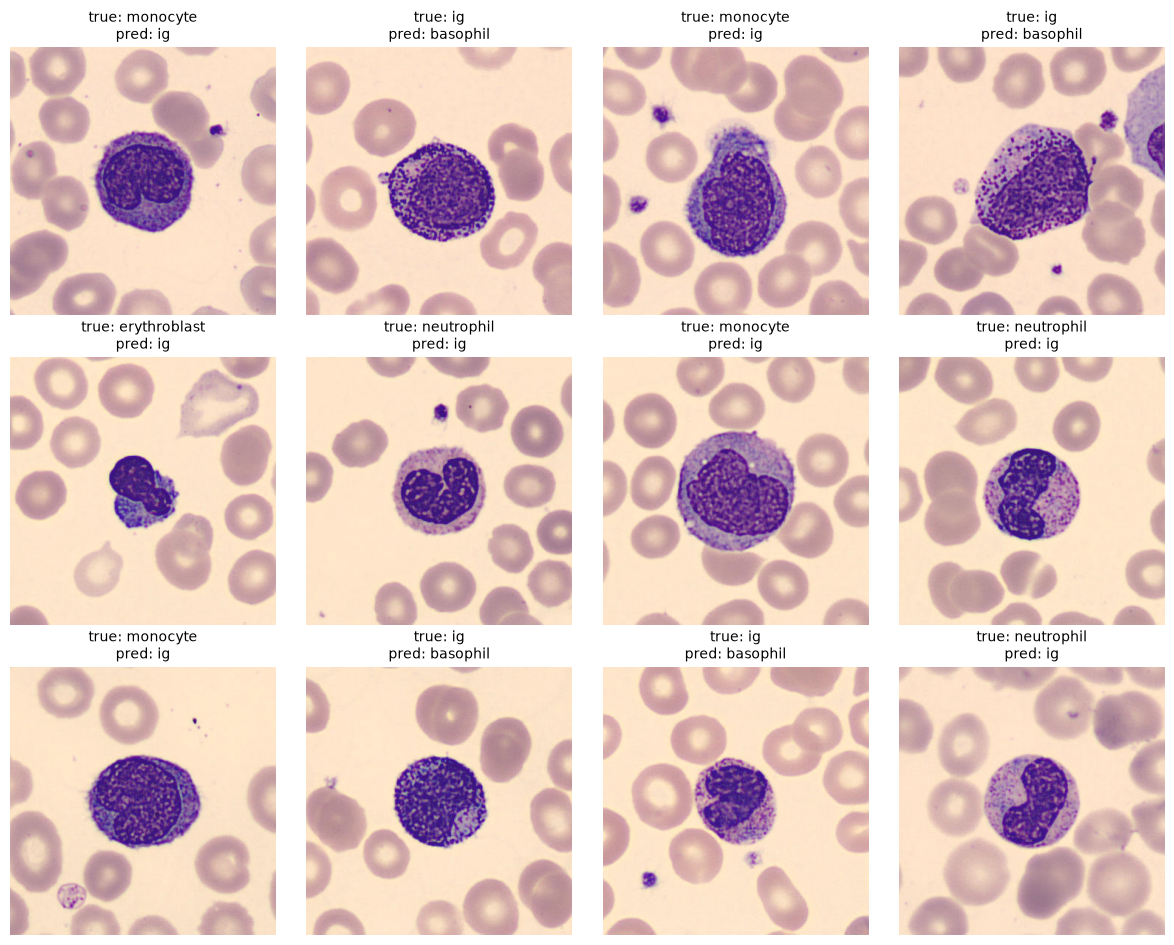

In [8]:
import json

wrong = np.where(y_true != y_pred)[0]
print(f"{len(wrong)} misclassified of {len(y_true)}")

rng = np.random.default_rng(SEED)
show = rng.choice(wrong, size=12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(12, 9.5))
for ax, i in zip(axes.flat, show):
    path, _ = split["test"][i]
    ax.imshow(Image.open(data_dir / path))
    ax.set_title(f"true: {class_names[y_true[i]]}\npred: {class_names[y_pred[i]]}", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.savefig("../images/blood_run1_misclassified.png", dpi=200, bbox_inches="tight")
plt.show()

with open("../results/blood_run1_test_predictions.json", "w") as f:
    json.dump({"y_true": y_true.tolist(), "y_pred": y_pred.tolist()}, f)

